# M5 Forecasting - Accuracy

### Overview
we have **3049 individual products from 3 categories and 7 departments, sold in 10 stores in 3 states**. To forecast the unit sales of Walmart products sold across **three U.S. states** (`CA`, `TX`, and `WI`) for multiple future time horizons: 1 month, 3 months, 6 months, 9 months, 1 year. [Kaggle Competition Link](https://www.kaggle.com/competitions/m5-forecasting-accuracy/data)

### Files
- calendar.csv
    Contains information about the dates on which the products are sold.

    date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI (whether SANP benefits were active on a given day in that state)

- sales_train_validation.csv 
    Historical daily unit sales data per product and store from `d_1` to `d_1913`.

    id,item_id,dept_id,cat_id,store_id,state_id,d_1, ...d_1913

- sales_train_evaluation.csv  
    Same as the validation file, but includes sales from `d_1` to `d_1941`. 

- sell_prices.csv
    Contains the price of each product sold at a particular store and date.

    store_id,item_id,wm_yr_wk,sell_price

- sample_submission.csv 

procedure: EDA, feature engineering, fitting, evaluating.
possible factors: 
- different time series by state, store, cat, dept
- the effect of disaster and weather on sales
- anomaly of sales
- "out of stock"


### Load Datasets

In [140]:
import pandas as pd
import numpy as np

# Load datasets
sales = pd.read_csv('m5-forecasting-accuracy/sales_train_validation.csv')
calendar = pd.read_csv('m5-forecasting-accuracy/calendar.csv')
sell_price = pd.read_csv('m5-forecasting-accuracy/sell_prices.csv')

In [103]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [104]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [105]:
sell_price.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [106]:
missing_values = sales.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [128]:
sales_long = pd.melt(
    sales,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

# Merge with calendar
sales_long = sales_long.merge(calendar[['d', 'date', 'wm_yr_wk', 'wday', 'month', 'event_name_1','event_name_2']], on='d', how='left')
sales_long['date'] = pd.to_datetime(sales_long['date'])

In [129]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,event_name_1,event_name_2
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,NaN,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,NaN,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,NaN,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,NaN,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,NaN,NaN


### EDA

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

#### sales by item category

/var/folders/hl/fwsfjj5x7s1c000w5q0t9z8r0000gp/T/ipykernel_35832/1789959118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


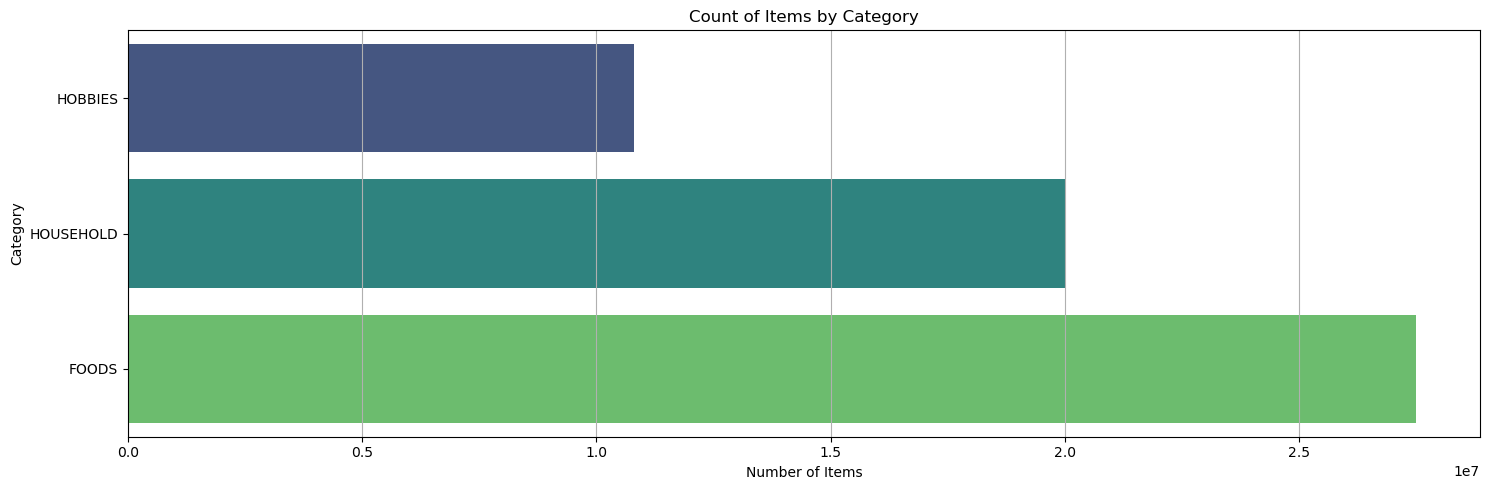

In [110]:
cat_counts = sales_long.groupby('cat_id')['id'].count().sort_values()

plt.figure(figsize=(15, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')

plt.title('Count of Items by Category')
plt.xlabel('Number of Items')
plt.ylabel('Category')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

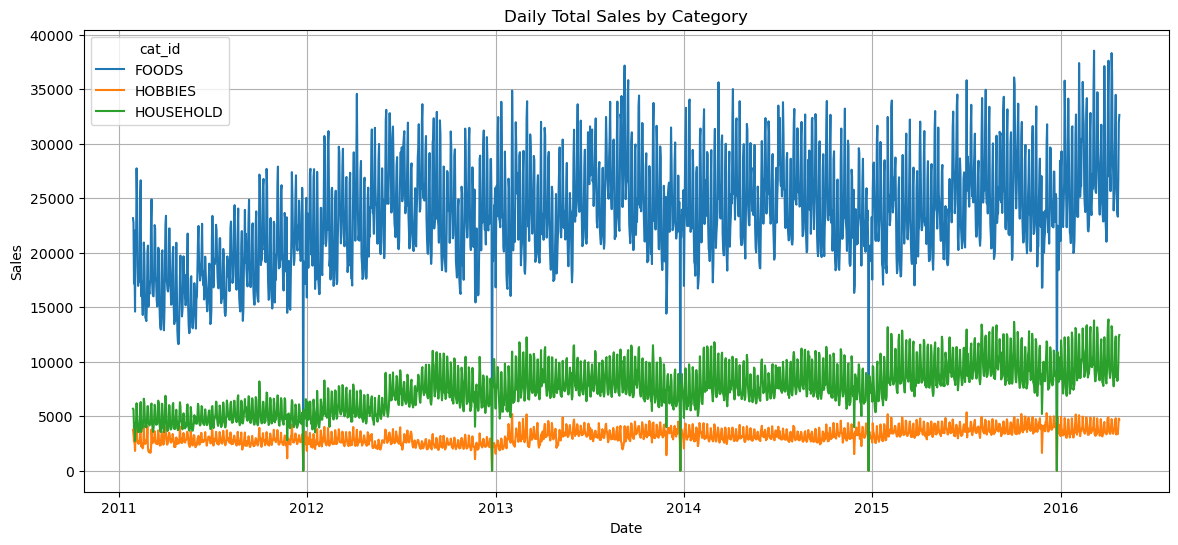

In [52]:
# Group by date and item category
category_sales = sales_long.groupby(['cat_id', 'date'])['sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=category_sales, x='date', y='sales', hue='cat_id')
plt.title('Daily Total Sales by Category')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

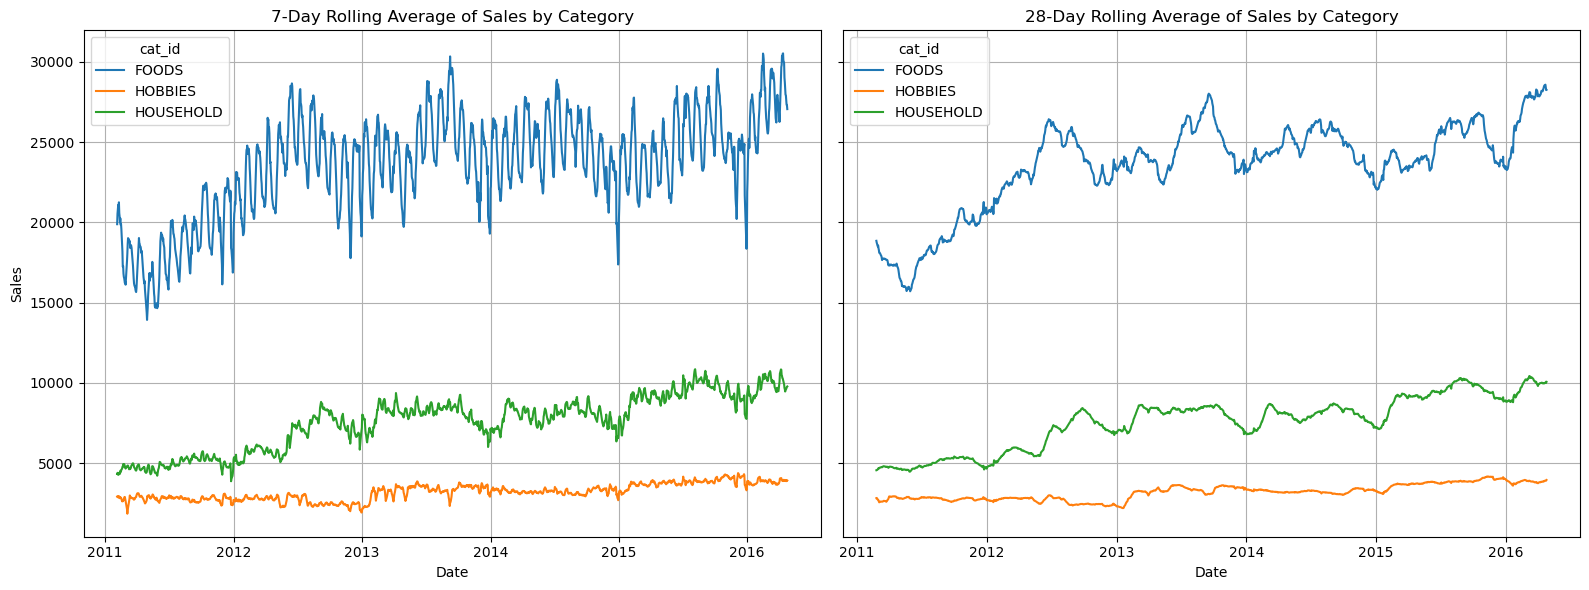

In [63]:
# Calculate rolling averages
category_sales['rolling_7'] = category_sales.groupby('cat_id')['sales'].transform(lambda x: x.rolling(7).mean())
category_sales['rolling_28'] = category_sales.groupby('cat_id')['sales'].transform(lambda x: x.rolling(28).mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.lineplot(data=category_sales, x='date', y='rolling_7', hue='cat_id', ax=axes[0])
axes[0].set_title('7-Day Rolling Average of Sales by Category')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].grid(True)

sns.lineplot(data=category_sales, x='date', y='rolling_28', hue='cat_id', ax=axes[1])
axes[1].set_title('28-Day Rolling Average of Sales by Category')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales')
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### sales by state

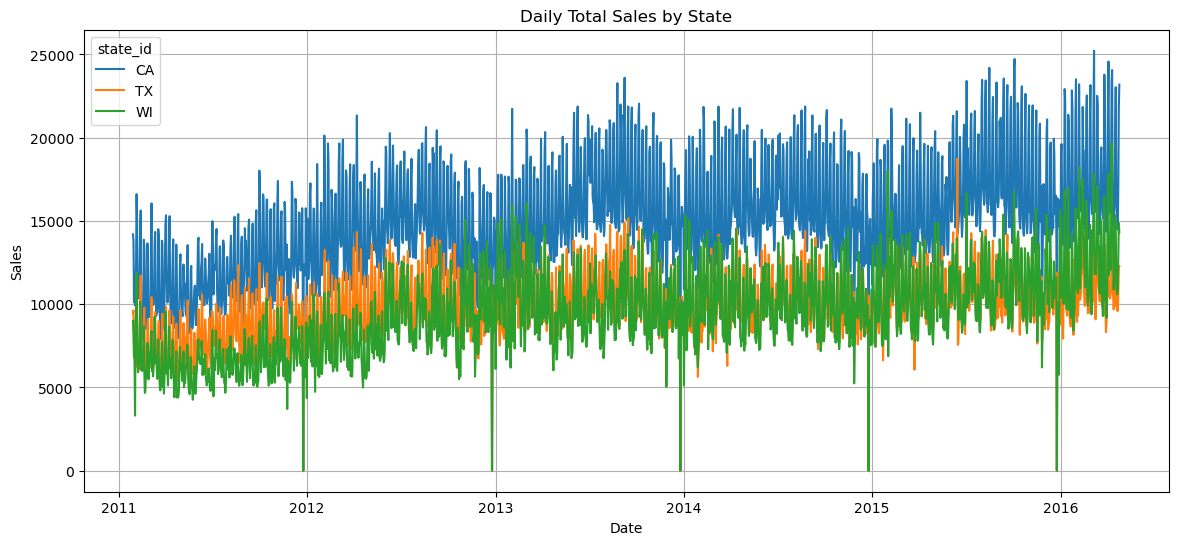

In [112]:
# Group by date and state
state_sales = sales_long.groupby(['state_id', 'date'])['sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=state_sales, x='date', y='sales', hue='state_id')
plt.title('Daily Total Sales by State')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [113]:
low_sales_days = state_sales[state_sales['sales'] < 100]
print(low_sales_days)

     state_id       date  sales
330        CA 2011-12-25      8
696        CA 2012-12-25      6
1061       CA 2013-12-25      5
1426       CA 2014-12-25      6
1791       CA 2015-12-25      6
2243       TX 2011-12-25      2
2609       TX 2012-12-25      2
2974       TX 2013-12-25     13
3339       TX 2014-12-25     13
3704       TX 2015-12-25      4
4156       WI 2011-12-25      3
4522       WI 2012-12-25      3
4887       WI 2013-12-25      2
5252       WI 2014-12-25      1
5617       WI 2015-12-25      4


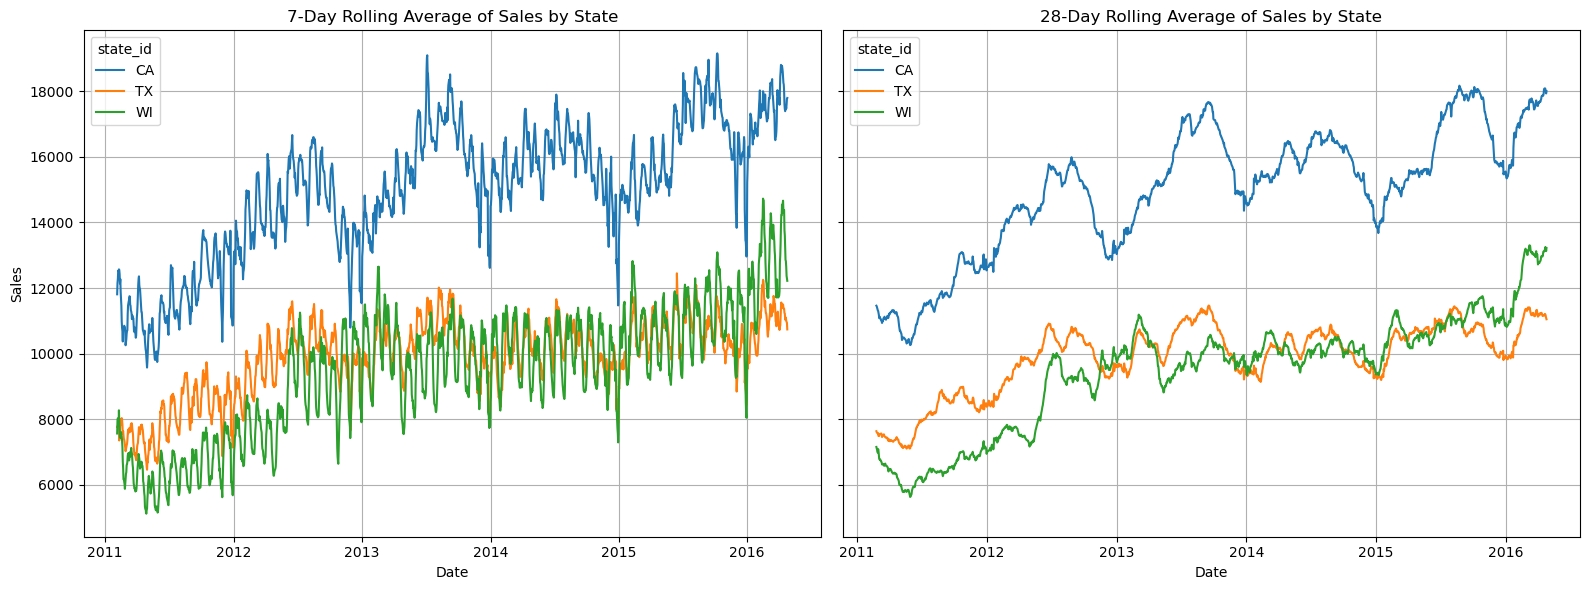

In [ ]:
state_sales['rolling_7'] = state_sales.groupby('state_id')['sales'].transform(lambda x: x.rolling(7).mean())
state_sales['rolling_28'] = state_sales.groupby('state_id')['sales'].transform(lambda x: x.rolling(28).mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.lineplot(data=state_sales, x='date', y='rolling_7', hue='state_id', ax=axes[0])
axes[0].set_title('7-Day Rolling Average of Sales by State')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].grid(True)

sns.lineplot(data=state_sales, x='date', y='rolling_28', hue='state_id', ax=axes[1])
axes[1].set_title('28-Day Rolling Average of Sales by State')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### sale by store

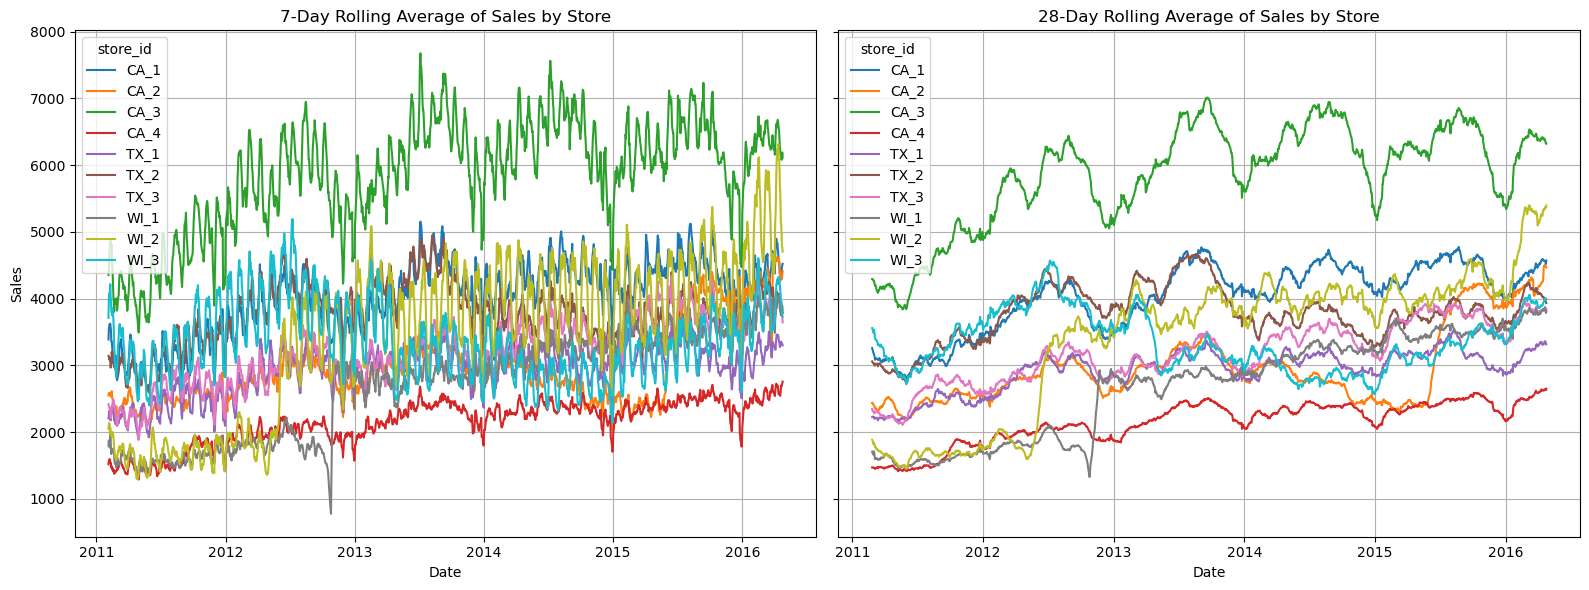

In [75]:
# Group by date and store
store_sales = sales_long.groupby(['store_id', 'date'])['sales'].sum().reset_index()

store_sales['rolling_7'] = store_sales.groupby('store_id')['sales'].transform(lambda x: x.rolling(7).mean())
store_sales['rolling_28'] = store_sales.groupby('store_id')['sales'].transform(lambda x: x.rolling(28).mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.lineplot(data=store_sales, x='date', y='rolling_7', hue='store_id', ax=axes[0])
axes[0].set_title('7-Day Rolling Average of Sales by Store')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].grid(True)

sns.lineplot(data=store_sales, x='date', y='rolling_28', hue='store_id', ax=axes[1])
axes[1].set_title('28-Day Rolling Average of Sales by Store')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### other factors

<Axes: title={'center': 'Top 10 Events by Average Sales'}, ylabel='event_name_1'>

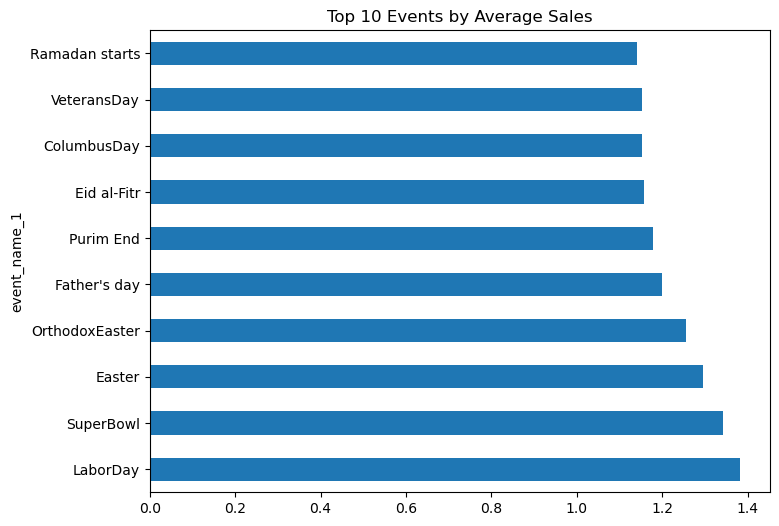

In [33]:
event_sales = sales_long.merge(calendar[['d', 'event_name_1', 'event_type_1']], on='d', how='left')
event_sales['has_event'] = event_sales['event_name_1'].notnull()

top_events = event_sales[event_sales['event_name_1'].notnull()]
top_events = top_events.groupby('event_name_1')['sales'].mean().sort_values(ascending=False).head(10)

top_events.plot(kind='barh', figsize=(8, 6), title='Top 10 Events by Average Sales')

#### random specific item

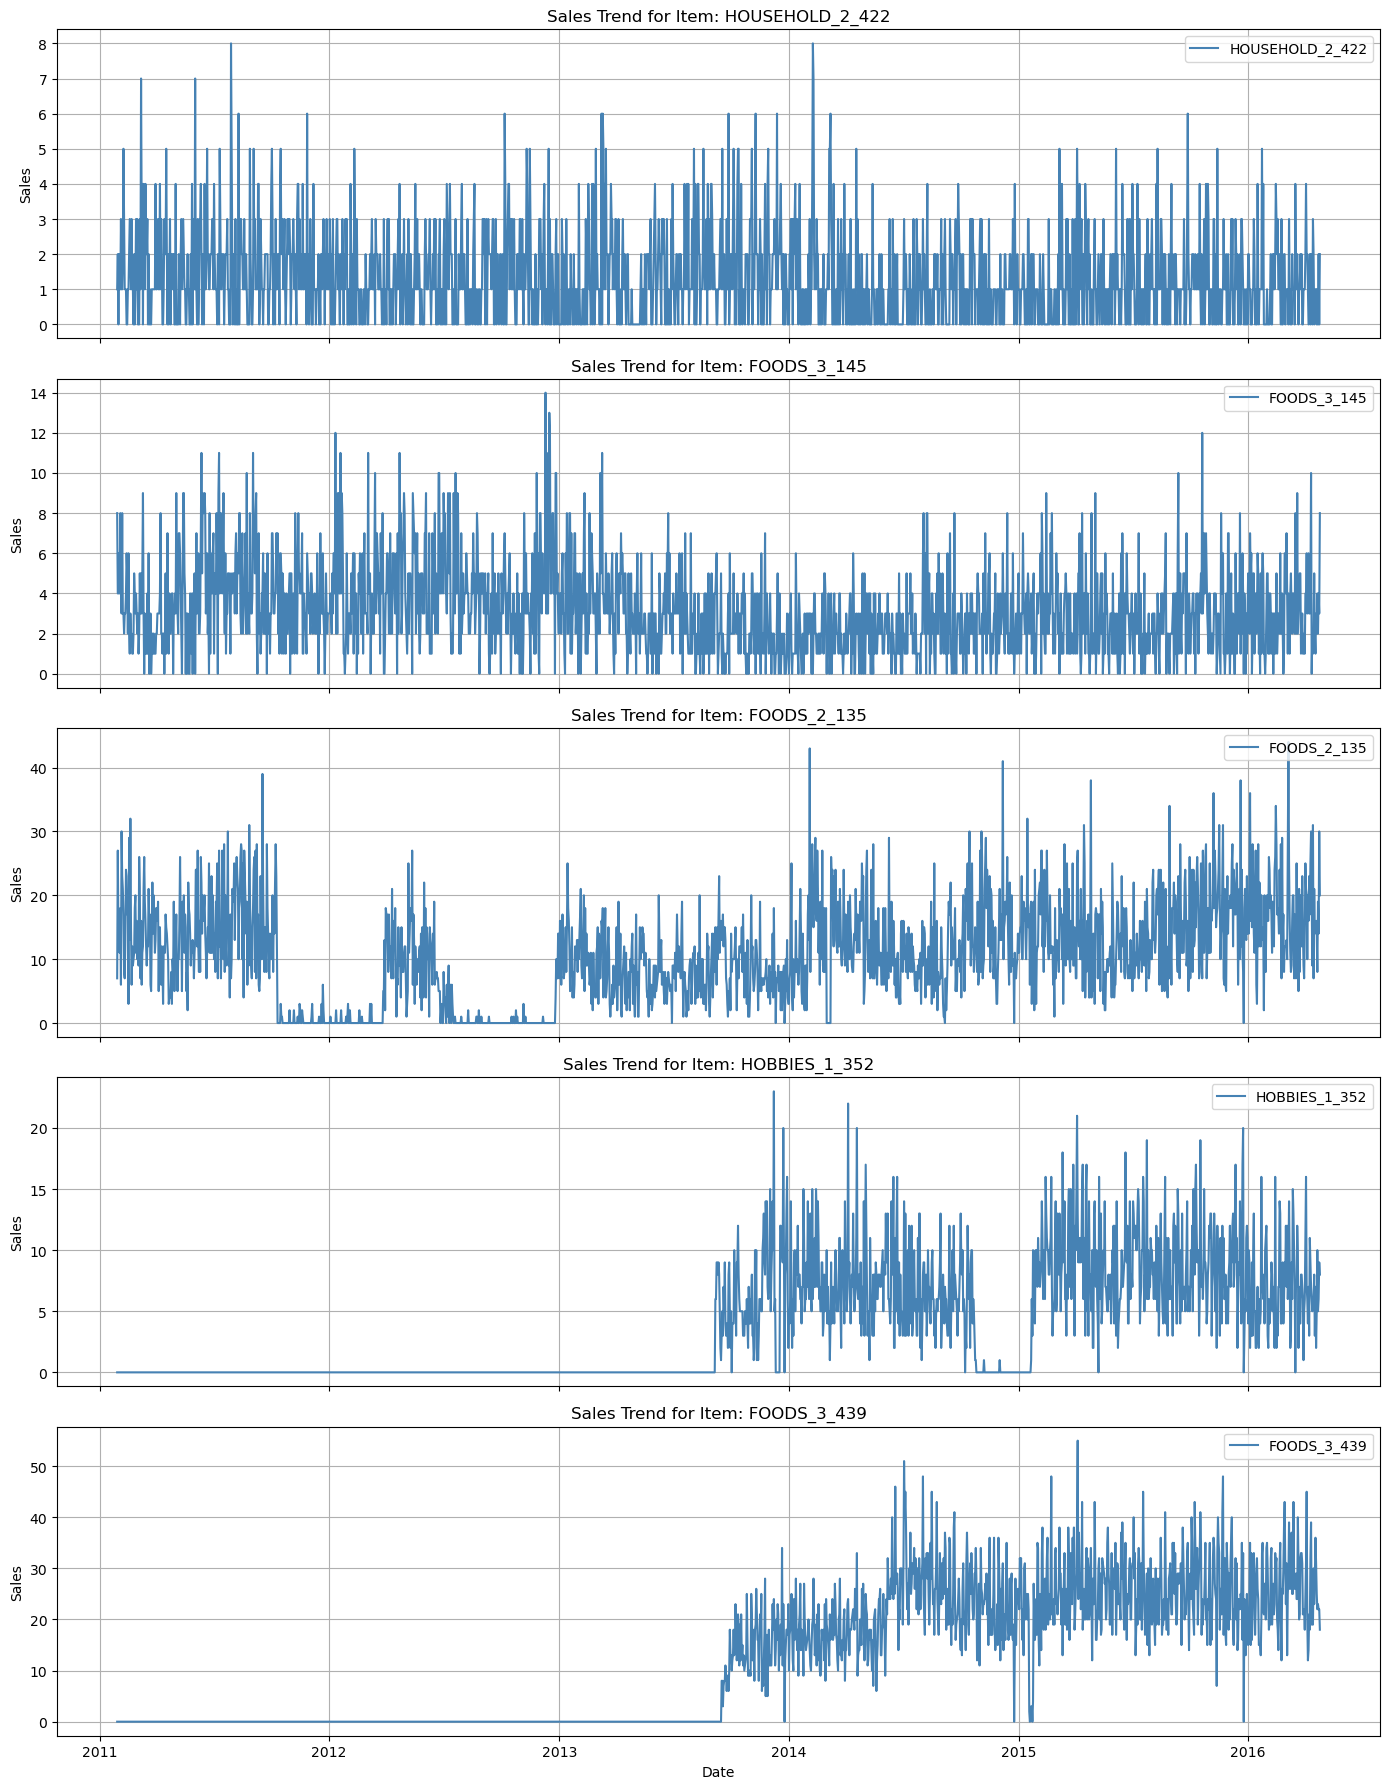

In [80]:
random_seed = 42
random_items = sales_long['item_id'].drop_duplicates().sample(5, random_state=random_seed).values

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for i, item_id in enumerate(random_items):
    item_data = sales_long[sales_long['item_id'] == item_id]
    daily_sales = item_data.groupby('date')['sales'].sum().reset_index()

    axes[i].plot(daily_sales['date'], daily_sales['sales'], label=f"{item_id}", color='steelblue')
    axes[i].set_title(f"Sales Trend for Item: {item_id}", fontsize=12)
    axes[i].set_ylabel("Sales")
    axes[i].grid(True)
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

#### potential out of stock
define "out of stock" as:
 - Sales = 0
 - Day before and day after had positive sales (i.e. demand likely existed)

In [ ]:
# Create lag and lead columns to check previous and next days' sales
sales_long['lag_sales'] = sales_long.groupby('id')['sales'].shift(1)  
sales_long['lead_sales'] = sales_long.groupby('id')['sales'].shift(-1) 

# Detect sequences of consecutive zero sales
sales_long['is_zero_sales'] = sales_long['sales'] == 0

# A stockout: 1. consecutive zeros 2. surrounding days have sales > 0.

def detect_stockout(df):
    stockout_flags = []
    
    for i in range(1, len(df) - 1):
        # If we find consecutive zeros, check the previous and next sales
        if df.iloc[i]['is_zero_sales'] and df.iloc[i-1]['sales'] > 0 and df.iloc[i+1]['sales'] > 0:
            stockout_flags.append(True)
        else:
            stockout_flags.append(False)
    
    # Add the first and last row 
    stockout_flags.insert(0, False) 
    stockout_flags.append(False) 
    
    return stockout_flags

sales_long['is_out_of_stock'] = detect_stockout(sales_long)

out_of_stock_days = sales_long[sales_long['is_out_of_stock'] == True]
out_of_stock_days[['id', 'date', 'sales', 'lag_sales', 'lead_sales', 'is_out_of_stock']]

,id,date,sales,lag_sales,lead_sales,is_out_of_stock
58,HOBBIES_1_060_CA_1_validation,2011-01-29,0,NaN,0.0,True
82,HOBBIES_1_085_CA_1_validation,2011-01-29,0,NaN,0.0,True
84,HOBBIES_1_087_CA_1_validation,2011-01-29,0,NaN,0.0,True
97,HOBBIES_1_102_CA_1_validation,2011-01-29,0,NaN,0.0,True
102,HOBBIES_1_107_CA_1_validation,2011-01-29,0,NaN,0.0,True
...,...,...,...,...,...,...
58327329,FOODS_3_787_WI_3_validation,2016-04-24,0,1.0,NaN,True
58327338,FOODS_3_796_WI_3_validation,2016-04-24,0,1.0,NaN,True
58327341,FOODS_3_799_WI_3_validation,2016-04-24,0,1.0,NaN,True
58327355,FOODS_3_813_WI_3_validation,2016-04-24,0,1.0,NaN,True


#### sale price

In [120]:
sell_price['category'] = sell_price['item_id'].apply(lambda x: x.split('_')[0])

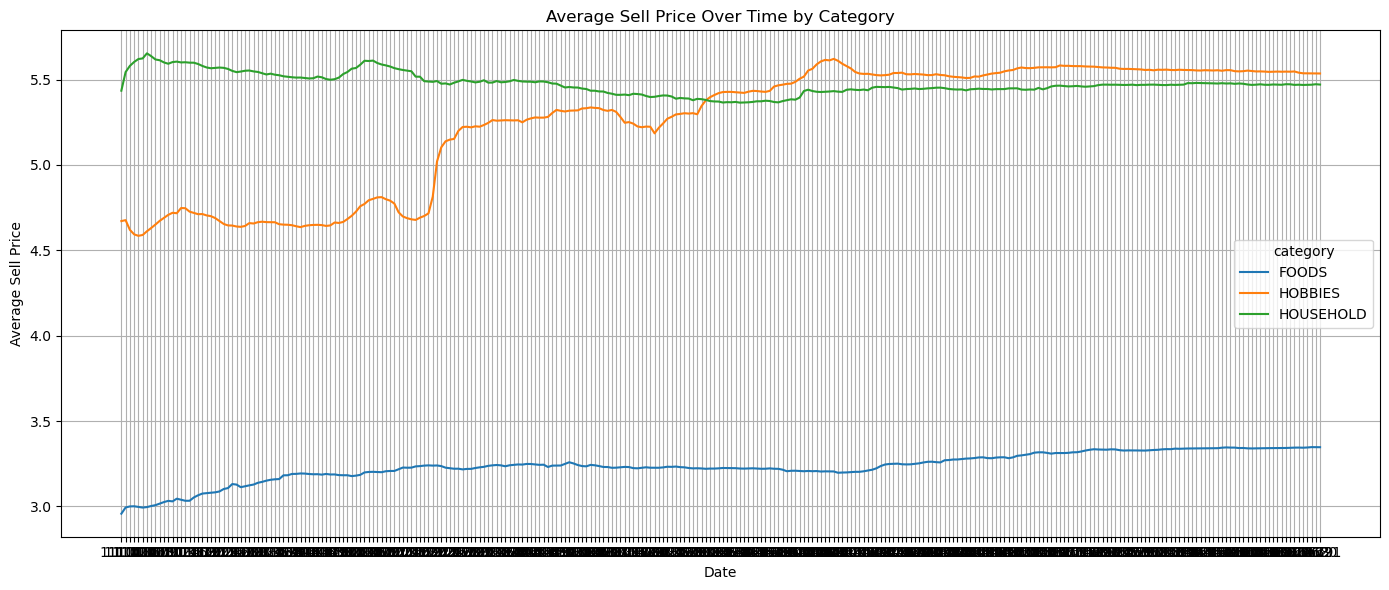

In [123]:
price_trend = sell_price.groupby(['wm_yr_wk', 'category'])['sell_price'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=price_trend, x='wm_yr_wk', y='sell_price', hue='category')
plt.title('Average Sell Price Over Time by Category')
plt.xlabel('Date')
plt.ylabel('Average Sell Price')
plt.grid(True)
plt.tight_layout()
plt.show()

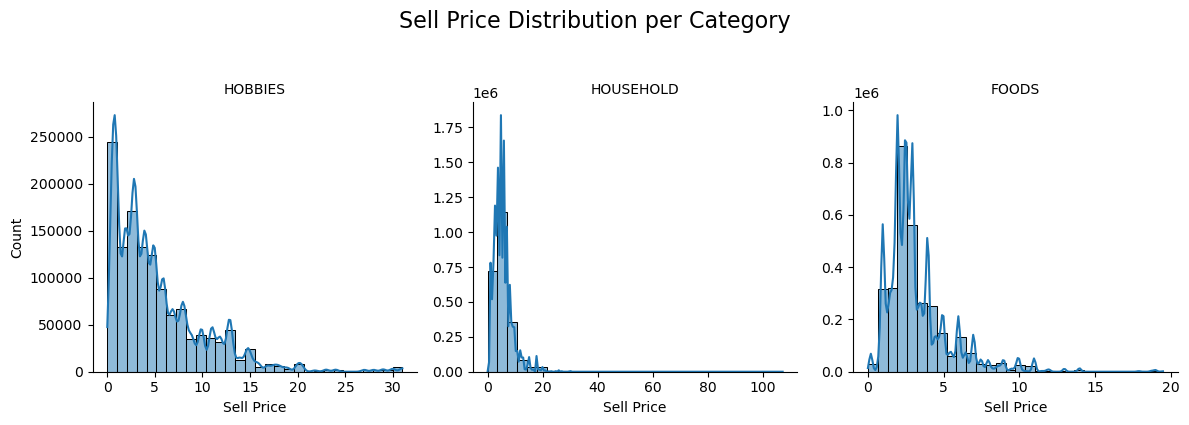

In [126]:
g = sns.FacetGrid(sell_price, col="category", col_wrap=3, height=4, sharex=False, sharey=False)
g.map(sns.histplot, "sell_price", bins=30, kde=True)

g.set_titles("{col_name}")
g.set_axis_labels("Sell Price", "Count")
plt.suptitle("Sell Price Distribution per Category", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

### Feature Engineering
- lag features: sales on previous days (lag1, lag7, lag30, etc.)
- rolling features: rolling averages or rolling sums to capture longer-term trends.
- event features: holiday 
- price features or SNAP

### Modeling Tryouts

In [139]:
# train test split
d_cols=[c for c in sales.columns if 'd_' in c]
train_dataset = sales[d_cols[-100:-30]]
val_dataset = sales[d_cols[-30:]]

print(val_dataset.values)

[[1 1 1 ... 0 1 1]
 [1 1 1 ... 0 0 0]
 [1 0 0 ... 1 1 1]
 ...
 [0 1 1 ... 0 1 0]
 [2 4 3 ... 3 1 3]
 [0 5 7 ... 0 0 0]]


In [ ]:
def plot_graphs(ids=[0,2], pred=[], pred_value=False):
    fig, axs = plt.subplots(len(ids), 1, figsize=(20,5))
    if len(ids)!=1 : axs = axs.flatten()
    
    if len(ids)==1:
        axs.plot(list(train_dataset.loc[ids[0]].keys()), train_dataset.loc[ids[0]].values)
        axs.plot(list(val_dataset.loc[ids[0]].keys()), val_dataset.loc[ids[0]].values)
        if pred_value and pred.any():
            axs.plot(list(val_dataset.loc[ids[0]].keys()), pred[ids[0]])
        axs.tick_params(axis='x', rotation=90)
    else:
        ax_id=0
        for i in ids:
            axs[ax_id].plot(list(train_dataset.loc[i].keys()), train_dataset.loc[i].values)
            axs[ax_id].plot(list(val_dataset.loc[i].keys()), val_dataset.loc[i].values)
            if pred_value and pred.any():
                axs[ax_id].plot(list(val_dataset.loc[i].keys()), pred[i])
            axs[ax_id].tick_params(axis='x', rotation=90)
            ax_id+=1
    plt.suptitle('Plot of few items with train and validation data respectively')
    plt.tight_layout()
    plt.show()   

#### MA

In [ ]:
# Moving average - Take past 30 days into consideration to predict the future values
def moving_average(window=30):
    predictions = []
    for i in range(0, len(val_dataset.columns)):
        if i==0:
            predictions.append(np.mean(train_dataset[train_dataset.columns[-window:]].values, axis=1))
        if i>0 and i<=window:
            predictions.append(np.mean(train_dataset[train_dataset.columns[-window+i:]].values, axis=1) + np.mean(val_dataset[val_dataset.columns[:i]].values, axis=1))
        if i>(window+1):
            predictions.append(np.mean(val_dataset[val_dataset.columns[:i]].values, axis=1))
    predictions=np.transpose(np.array([list(row) for row in predictions]))
    error_norm = np.linalg.norm(predictions[:3]-val_dataset[:3]/len(predictions[0]))
    return predictions, float(error_norm)

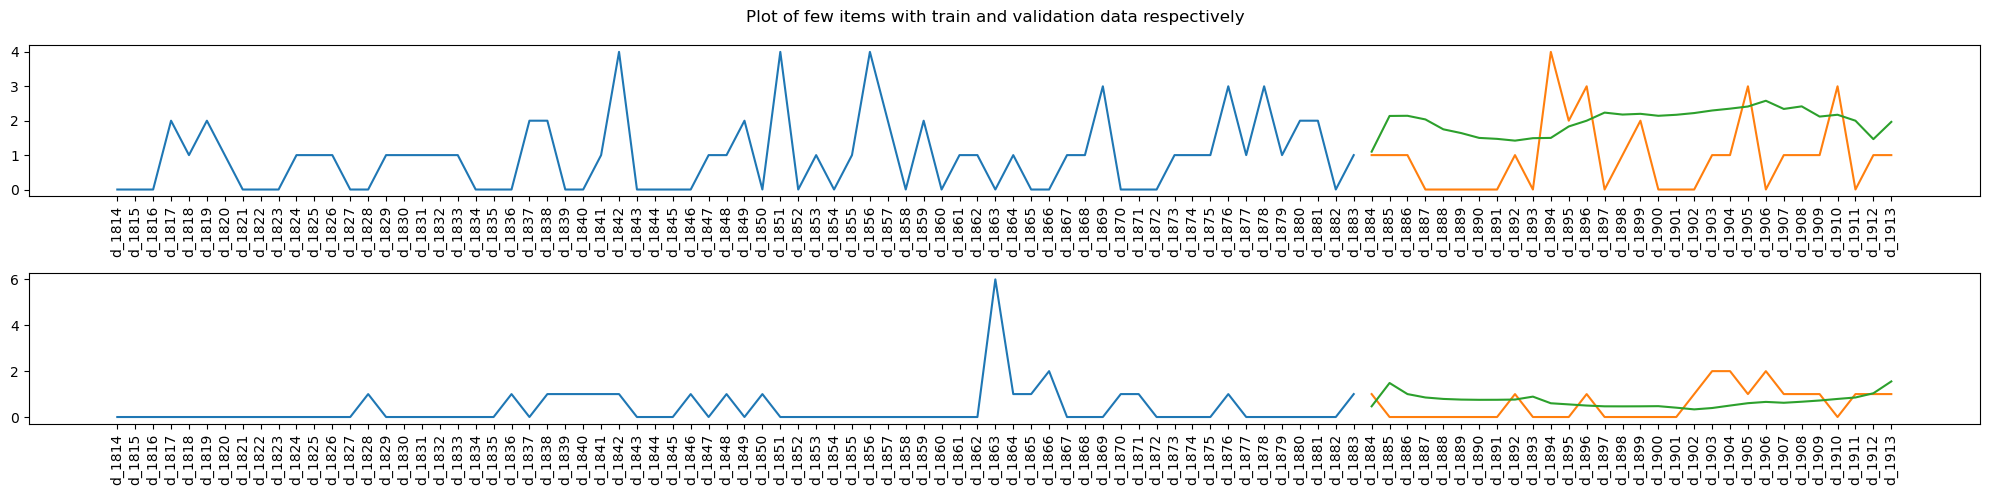

In [ ]:
# predict for 2 items
ids=[0, 2]
pred, error_moving = moving_average()
plot_graphs(ids, pred, True)

#### ARIMA with differnt differencing methods

In [188]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [225]:
# ADF stationarity check
# Extract the last 30 days of sales data for one specific item as a 1D array
series = train_dataset[train_dataset.columns[-60:]].values[2]
result = adfuller(series)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
if result[1] < 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")

ADF Statistic: -6.807811812058935
p-value: 2.1542500807427975e-09
The series is stationary


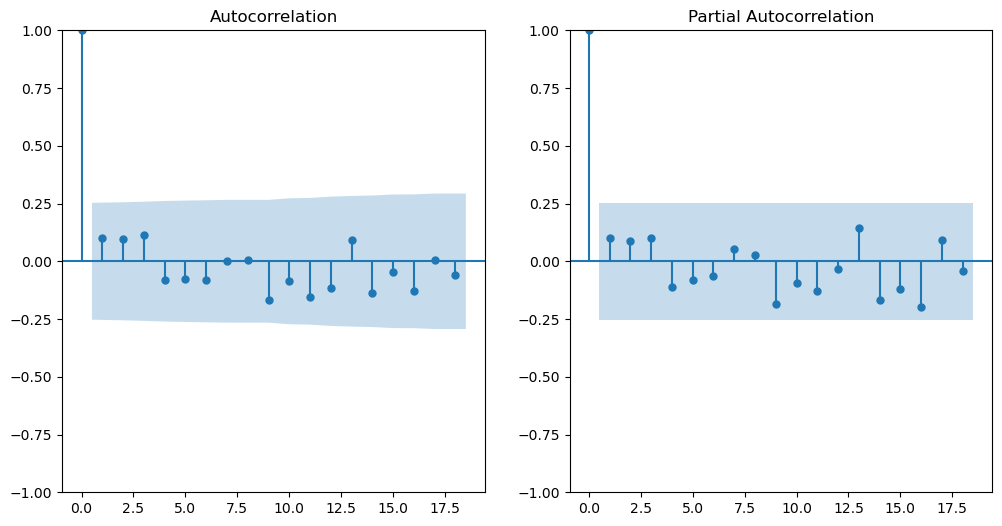

In [226]:
# ACF(q) and PACF(p)
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(series, ax=plt.gca())
plt.subplot(122)
plot_pacf(series, ax=plt.gca())
plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

AIC: 184.480483722535
AIC: 68.3697577551309
AIC: 161.85162190832443


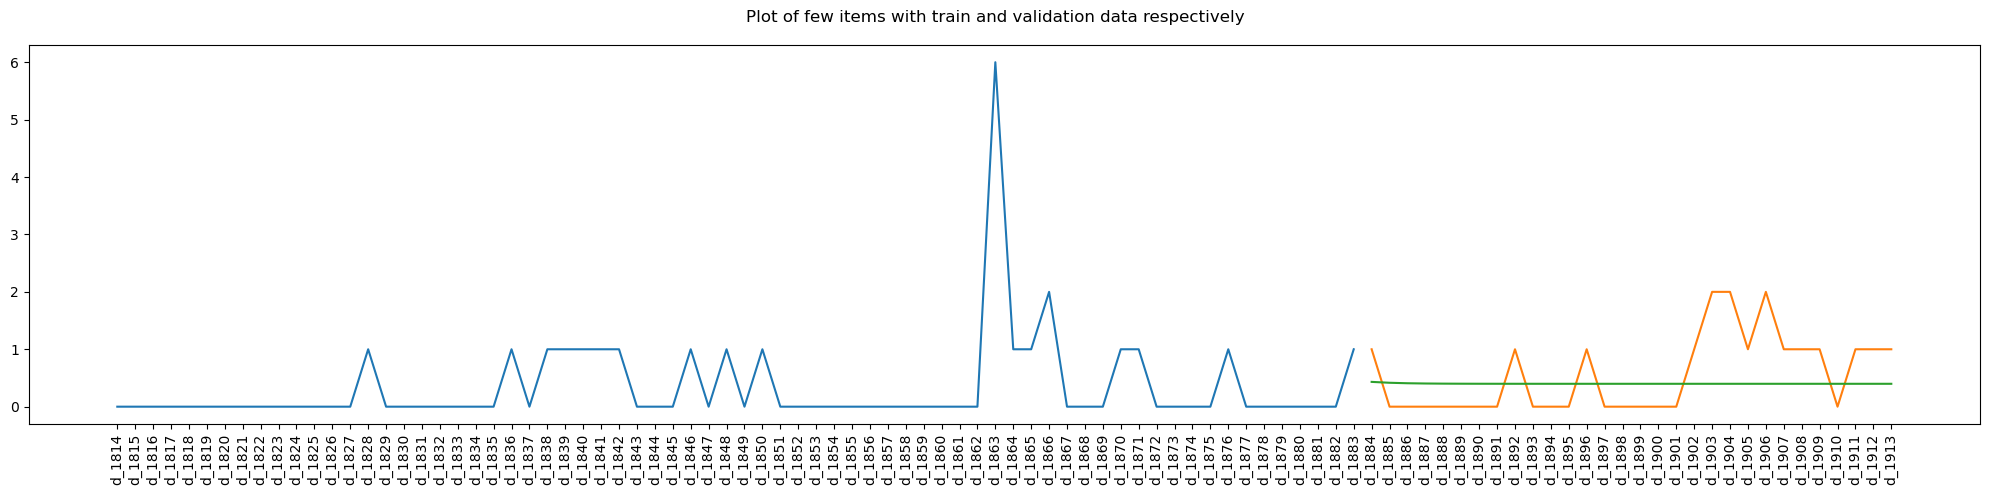

In [229]:
from tqdm.notebook import tqdm as tqdm
def arima_101():
    predictions = []

    # use the last 90 days of training data
    for row in tqdm(train_dataset[train_dataset.columns[-60:]].values[:3]):
        # Fit ARIMA(1,1,1)
        model = ARIMA(row, order=(1, 0, 1))
        fit = model.fit()

        # Forecast 30 steps ahead
        forecast = fit.forecast(steps=30)
        predictions.append(forecast)
        print(f"AIC: {fit.aic}")

    predictions = np.array(predictions).reshape(-1, 30)

    # compute a simple error against validation set
    error_norm = np.linalg.norm(predictions - val_dataset[:3].values) / len(predictions[0])

    return predictions, float(error_norm)

ids = [2]
pred, error_arima = arima_101()
plot_graphs(ids, pred, True)

In [230]:
# ADF stationarity check
# Extract the last 30 days of sales data for one specific item as a 1D array
series = train_dataset[train_dataset.columns[-30:]].values[2]
result = adfuller(series)
print(train_dataset[train_dataset.columns[-30:]].values)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
if result[1] < 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")

[[0 1 4 ... 2 0 1]
 [1 0 0 ... 0 1 1]
 [0 0 0 ... 0 0 1]
 ...
 [0 0 2 ... 0 0 2]
 [0 0 0 ... 2 1 1]
 [0 1 4 ... 5 3 2]]
ADF Statistic: -2.3516987258045967
p-value: 0.15583549661055074
The series is non-stationary


In [231]:
# First-order differencing
original_series = train_dataset[train_dataset.columns[-30:]].values[2] 
differenced_series = pd.Series(original_series).diff().dropna()

# Check stationarity again
result_diff = adfuller(differenced_series)
print(f"ADF Statistic (after differencing): {result_diff[0]}")
print(f"p-value: {result_diff[1]}")
if result_diff[1] < 0.05:
    print("The differenced series is stationary")
else:
    print("Still non-stationary")

ADF Statistic (after differencing): -2.883523945645119
p-value: 0.04729775877847451
The differenced series is stationary


In [232]:
print(len(differenced_series))

29


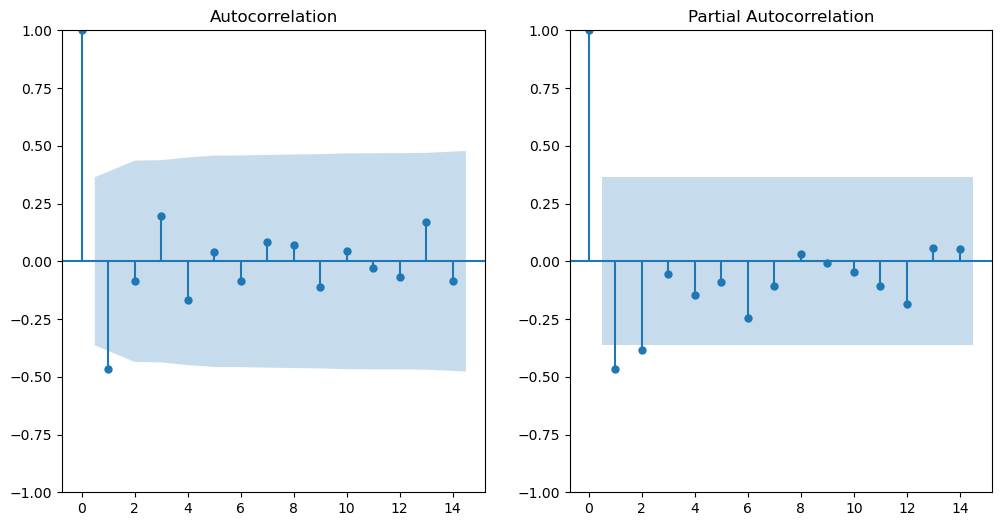

In [ ]:
# ACF(q) and PACF(p)
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(differenced_series, ax=plt.gca())
plt.subplot(122)
plot_pacf(differenced_series, ax=plt.gca())
plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

AIC: 213.09925353776654
AIC: 80.49199838489326
AIC: 179.2194458379872


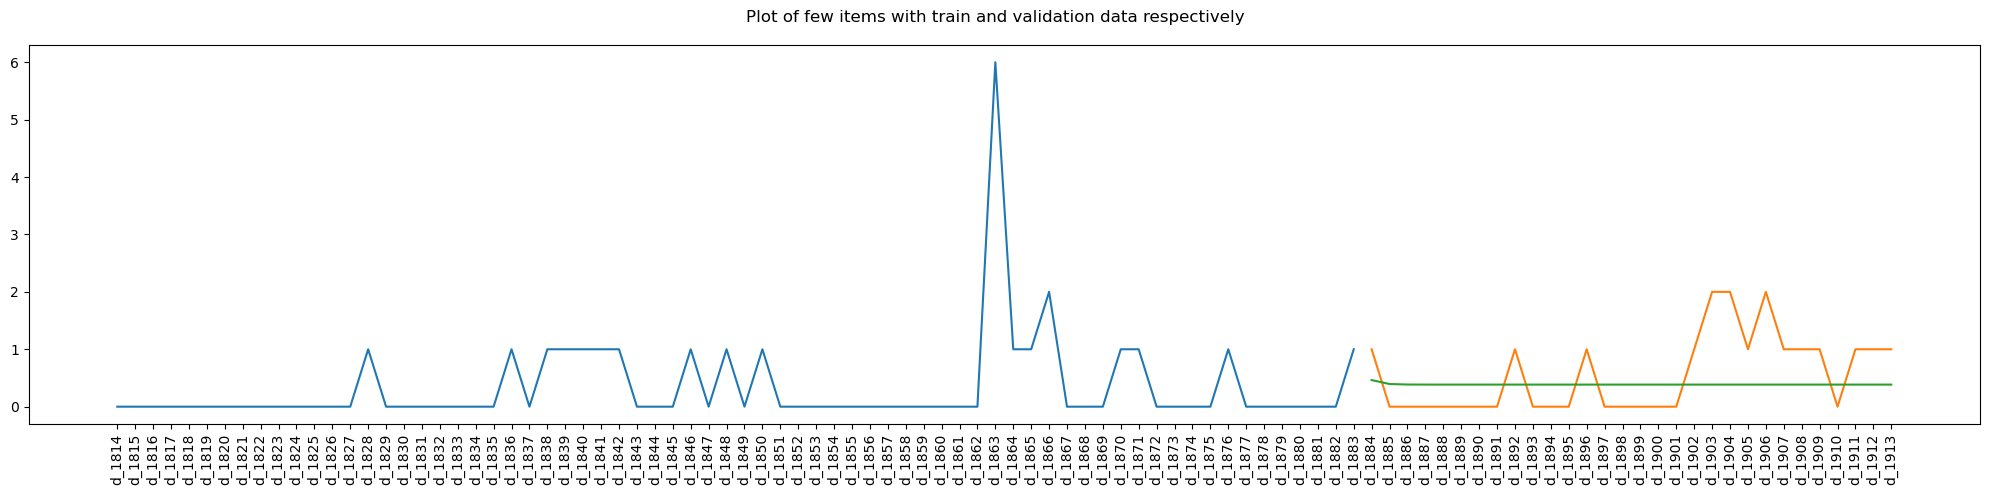

In [233]:
from tqdm.notebook import tqdm as tqdm
def arima_111():
    predictions = []

    # use the last 90 days of training data for the first 3 items
    for row in tqdm(train_dataset[train_dataset.columns[-90:]].values[:3]):
        # Fit ARIMA(1,1,1)
        model = ARIMA(row, order=(1, 1, 1))
        fit = model.fit()

        # Forecast 30 steps ahead
        forecast = fit.forecast(steps=30)
        predictions.append(forecast)
        print(f"AIC: {fit.aic}")

    predictions = np.array(predictions).reshape(-1, 30)

    # compute a simple error against validation set
    error_norm = np.linalg.norm(predictions - val_dataset[:3].values) / len(predictions[0])

    return predictions, float(error_norm)

ids = [2]
pred, error_arima = arima_111()
plot_graphs(ids, pred, True)

In [199]:
# Seasonal Differencing
example = (train_dataset[train_dataset.columns[-30:]].loc[2]).reset_index()
example.columns = ['index', 'sales']

# Number by which the seasonality is present, if the seasonal cycle is 1 cycle in 12 months then, we pass 12 
example['seasonal first difference'] = example['sales'] - example['sales'].shift(7) #For us it is 7 
#print(example)
adfuller_test(example['seasonal first difference'].dropna())

ADF test statistics:-1.2367414008368347
p-value:0.6575942439327382
#Lags used:9
No of observations used:13
Non-stationary


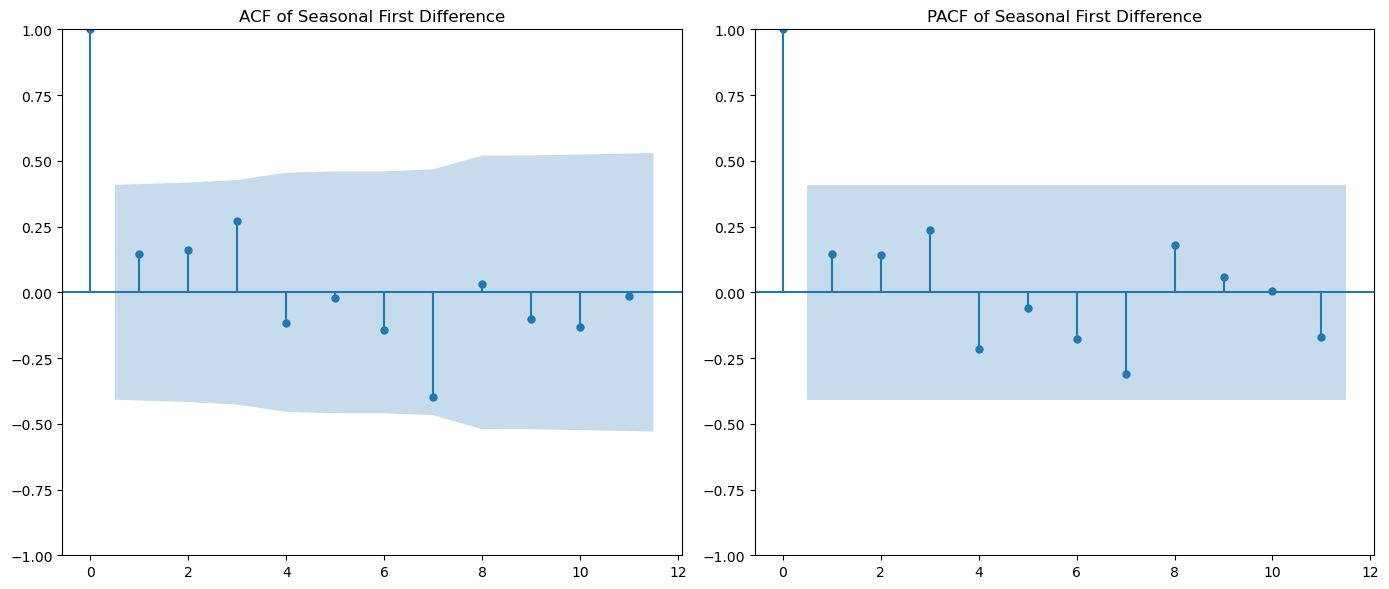

In [234]:
# ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(example['seasonal first difference'].dropna(), ax=axes[0])
axes[0].set_title('ACF of Seasonal First Difference')
plot_pacf(example['seasonal first difference'].dropna(), ax=axes[1])
axes[1].set_title('PACF of Seasonal First Difference')
plt.tight_layout()
plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

/opt/anaconda3/envs/M5/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


84.97018662859412
39.36668390681989
87.7271009848169


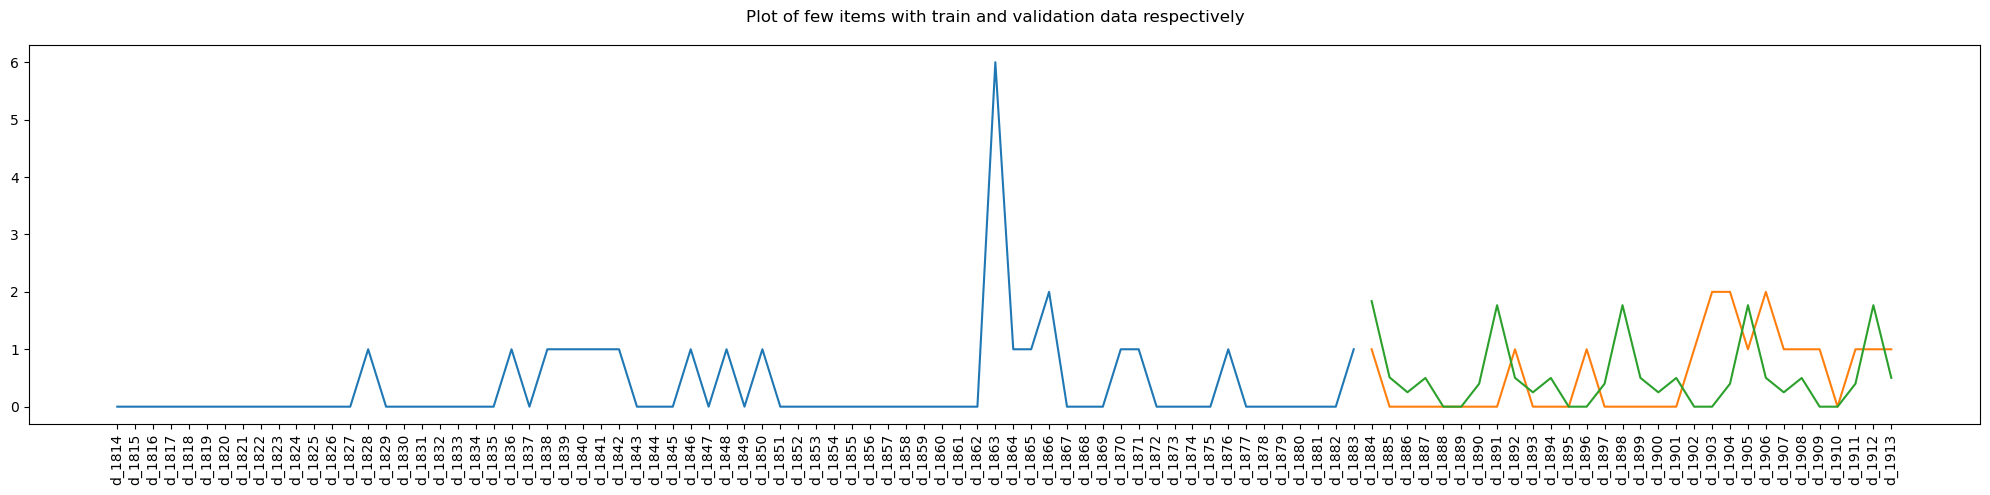

In [235]:
def arima():
    predictions = []
    for row in tqdm(train_dataset[train_dataset.columns[-30:]].values[:3]):
        fit = sm.tsa.statespace.SARIMAX(row, seasonal_order=(0,1,1,7)).fit()
        predictions.append(fit.forecast(30))
        print(fit.aic)
    predictions = np.array(predictions).reshape(-1, 30)
    error_norm = np.linalg.norm(predictions[:3]-val_dataset[:3]/len(predictions[0]))
    return predictions, float(error_norm)

ids = [2]
pred, error_arima = arima()
plot_graphs(ids, pred, True)